In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt


# Do experiment!

In [16]:
df = pd.read_csv("Dhaka Rent - Dhaka Rent.csv")


In [17]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 60 entries, 0 to 59
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   area    60 non-null     int64
 1   rent    60 non-null     int64
dtypes: int64(2)
memory usage: 1.1 KB


In [19]:
df.isnull().sum()

area    0
rent    0
dtype: int64

In [20]:
df.head()

,area,rent
0,2000,31500
1,2100,35000
2,2500,41050
3,2250,36100
4,3000,52100


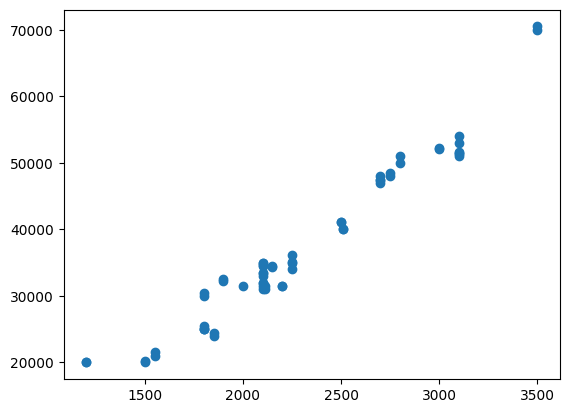

In [21]:
plt.scatter(df['area'], df['rent'])

Text(0.5, 1.0, 'Dhaka Rent')

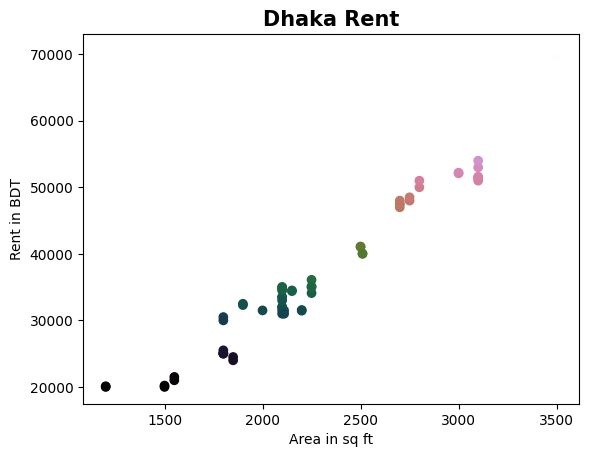

In [32]:
#plt.plot(df[['area']], df[['rent']])
plt.scatter(df['area'], 
            df['rent'],
            c = df['rent'],
            cmap = 'cubehelix',
           )
plt.xlabel('Area in sq ft')
plt.ylabel('Rent in BDT')
plt.title('Dhaka Rent', fontsize=15, weight= 'bold')

In [33]:
from sklearn.linear_model import LinearRegression

In [34]:
reg = LinearRegression()


In [36]:
reg.fit(df[['area']],df['rent'])

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [37]:
reg.coef_

array([21.29266147])

In [38]:
reg.intercept_

np.float64(-11469.735446431114)

In [39]:
reg.predict([[2100]])

C:\Users\shaha\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([33244.85364815])

In [43]:
reg.predict(df[['area']])

array([31115.58750079, 33244.85364815, 41761.9182376 , 36438.7528692 ,
       52408.2489744 , 28986.32135343, 20469.25676399, 27921.68827975,
       46020.45053232, 33244.85364815, 34309.48672183, 33244.85364815,
       33244.85364815, 41974.84485233, 36438.7528692 , 54537.51512177,
       26857.05520607, 21533.88983767, 26857.05520607, 46020.45053232,
       33457.78026289, 33244.85364815, 63054.57971121, 14081.4583219 ,
       48149.71667968, 54537.51512177, 47085.083606  , 26857.05520607,
       35374.11979552, 54537.51512177, 33244.85364815, 33244.85364815,
       41761.9182376 , 36438.7528692 , 52408.2489744 , 28986.32135343,
       20469.25676399, 27921.68827975, 46020.45053232, 33244.85364815,
       34309.48672183, 33244.85364815, 33244.85364815, 41974.84485233,
       36438.7528692 , 54537.51512177, 26857.05520607, 21533.88983767,
       26857.05520607, 46020.45053232, 33457.78026289, 33244.85364815,
       63054.57971121, 14081.4583219 , 48149.71667968, 54537.51512177,
      

In [50]:
df2= df.copy()

In [51]:
df2['predicted'] = reg.predict(df[['area']])
df2['predicted'] = df2['predicted'].round(2)

In [52]:
df2.head()

,area,rent,predicted
0,2000,31500,31115.59
1,2100,35000,33244.85
2,2500,41050,41761.92
3,2250,36100,36438.75
4,3000,52100,52408.25


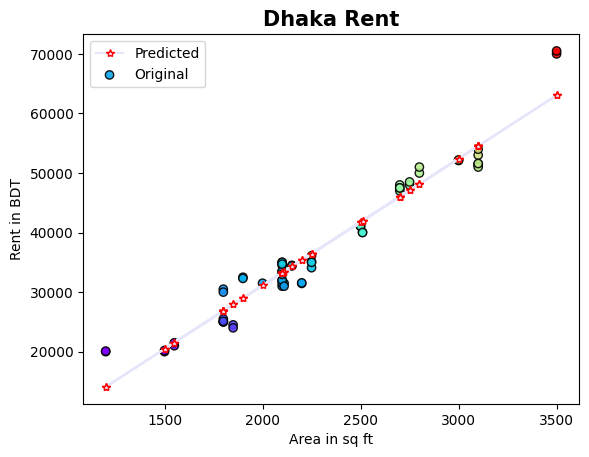

In [67]:
plt.plot(df[['area']], reg.predict(df[['area']]), 
         color = 'lavender',
         marker='*',
         #markerfacecolor= 'black',
         markeredgecolor = 'red',
         label = 'Predicted',
        )
plt.scatter(df['area'], 
            df['rent'],
            c = df['rent'],
            cmap = 'rainbow',
            alpha=.90,
            edgecolor= 'k',
            label = 'Original'
           )
plt.xlabel('Area in sq ft')
plt.ylabel('Rent in BDT')
plt.title('Dhaka Rent', fontsize=15, weight= 'bold')

plt.legend()
plt.show()

In [69]:
from sklearn.metrics import mean_squared_error

In [71]:
mean_squared_error(df[['rent']], df2['predicted'])

6778078.377273332

In [72]:
x = df['area']
y = df['rent']

In [73]:
dev_x = x - np.mean(x)
dev_y = y - np.mean(y)

m = np.sum(dev_x * dev_y)/ np.sum(dev_x ** 2)

In [74]:
m

np.float64(21.292661473611954)

In [75]:
c = np.mean(y) - (m*np.mean(x))
c

np.float64(-11469.7354464311)

In [76]:
df.head()

,area,rent
0,2000,31500
1,2100,35000
2,2500,41050
3,2250,36100
4,3000,52100


In [77]:
m*2100 + c


np.float64(33244.85364815401)